Step 1 - Import Libraries

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Step 2 - Load Dataset

In [3]:
# Importing the dataset (Ensure you have the CSV file 'Posisi_gaji.csv' in the same directory)
dataset = pd.read_csv('Posisi_gaji.csv')
X = dataset.iloc[:, 1:2].values
y = dataset.iloc[:, 2].values  # Convert to a single column

Step 3 - Feature Scaling

In [4]:
# Feature Scaling\
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
sc_y = StandardScaler()
X = sc_X.fit_transform(X.reshape(-1, 1))
y = sc_y.fit_transform(y.reshape(-1, 1))

Step 4 - Fitting the SVR Model

In [5]:
# Fitting SVR to the dataset
from sklearn.svm import SVR
regressor = SVR(kernel='rbf')
regressor.fit(X, y)

c:\Users\icha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR()

Step 5 - Visualising SVR Results

C:\Users\icha\AppData\Local\Temp\ipykernel_14872\946958165.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.01).reshape(-1, 1)


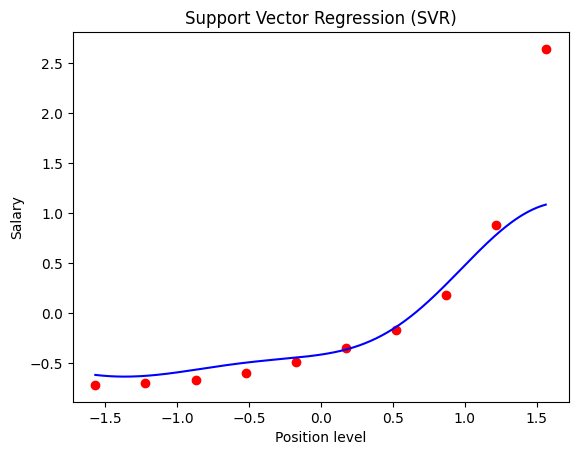

In [10]:
	# Visualising SVR results (higher resolution and smoother curve)
X_grid = np.arange(min(X), max(X), 0.01).reshape(-1, 1)
plt.scatter(X, y, color='red')
plt.plot(X_grid, regressor.predict(X_grid), color='blue')
plt.title('Support Vector Regression (SVR)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()

Step 6 - Predicting Results

In [11]:
	# Predicting results
	# Create a 2D array containing the position level to be predicted
position_level_pred = np.array([[6.5]])
	# Feature scaling for the data to be predicted
position_level_pred = sc_X.transform(position_level_pred)
	# Perform prediction using the SVR model
salary_pred = regressor.predict(position_level_pred)
	# Return the prediction to the original scale
salary_pred = sc_y.inverse_transform(salary_pred.reshape(-1, 1))

Step 7 - Displaying Results

In [12]:
# Displaying the prediction result
print("Predicted Salary for Position Level 6.5:", salary_pred[0])

Predicted Salary for Position Level 6.5: [170370.0204065]


Step 8 - Evaluating the SVR Model

In [13]:
	# Evaluating the model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
	
y_actual = y 
y_pred = regressor.predict(X)
	
# Calculating MAE
mae = mean_absolute_error(y_actual, y_pred)
	
	# Calculating MSE
mse = mean_squared_error(y_actual, y_pred)
	
	# Calculating RMSE
rmse = np.sqrt(mse)
	
	# Calculating R-squared
r2 = r2_score(y_actual, y_pred)
	
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R-squared:", r2)

MAE: 0.22299274095734414
MSE: 0.24839989293792014
RMSE: 0.4983973243687411
R-squared: 0.7516001070620798
